In [2]:
import torch
import torch.nn as nn
import torch.nn.utils.prune as prune
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

class TinyNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 8, 3, padding=1)
        self.conv2 = nn.Conv2d(8, 16, 3, padding=1)
        self.fc1   = nn.Linear(16 * 7 * 7, 64)
        self.fc2   = nn.Linear(64, 10)
        self.pool  = nn.MaxPool2d(2)
        self.relu  = nn.ReLU()

    def forward(self, x):
        x = self.pool(self.relu(self.conv1(x)))
        x = self.pool(self.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)
model = TinyNet()
model.load_state_dict(torch.load('tinynet_baseline_v1.pth'))
model.eval()
print("Baseline model loaded!")




Baseline model loaded!


In [3]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

test_data = torchvision.datasets.MNIST('./data', train=False,
                                        transform=transform, download=True)
test_loader = DataLoader(test_data, batch_size=64, shuffle=False)

In [4]:
def load_fresh_model():
    model = TinyNet()
    model.load_state_dict(torch.load('tinynet_baseline_v1.pth'))
    model.eval()
    return model
def evaluate(model, test_loader):
    model.eval()
    correct = 0 
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            output = model(images)
            _,predicted = torch.max(output,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100* correct/total
    print(f"Accuracy: {accuracy:.2f}%")
    return accuracy
sanity_check_model = load_fresh_model()
evaluate(sanity_check_model, test_loader)

Accuracy: 98.77%


98.77

In [5]:
def prune_model(model, amount):
    prune.l1_unstructured(model.conv1, name='weight', amount=amount)
    prune.l1_unstructured(model.conv2, name='weight', amount=amount)
    prune.l1_unstructured(model.fc1, name='weight', amount=amount)
    prune.l1_unstructured(model.fc2, name='weight', amount=amount)
    return model
for amount in [0.60, 0.65, 0.66, 0.67, 0.70]:
    model = load_fresh_model()
    model = prune_model(model, amount)
    print(f"Sparsity: {int(amount*100)}%", end=" | ")
    evaluate(model, test_loader)

Sparsity: 60% | Accuracy: 96.99%
Sparsity: 65% | Accuracy: 95.01%
Sparsity: 66% | Accuracy: 94.05%
Sparsity: 67% | Accuracy: 91.34%
Sparsity: 70% | Accuracy: 86.77%


# PRUNING ONE LAYER,LEAVING REST ALONE

In [6]:

def prune_single_layer(layer_name,amount):
    model = load_fresh_model()
    layer = getattr(model,layer_name)
    prune.l1_unstructured(layer, name ='weight', amount=amount)
    acc  =evaluate(model,test_loader)
    return acc


In [7]:
for layer_name in ['conv1','conv2','fc1','fc2']:
    acc  = prune_single_layer(layer_name,0.70)
    print(f"{layer_name}: {acc:.2f}%")


Accuracy: 98.46%
conv1: 98.46%
Accuracy: 97.98%
conv2: 97.98%
Accuracy: 98.68%
fc1: 98.68%
Accuracy: 97.03%
fc2: 97.03%


In [8]:
check_points = [0.60,0.61,0.62, 0.63, 0.64, 0.65, 0.66, 0.67, 0.68, 0.69, 0.70,0.71,0.72,0.73, 0.74, 0.75, 0.76, 0.77, 0.78, 0.79, 0.80]
results = {
    'conv1':[],
    'conv2':[],
    'fc1':[],
    'fc2':[]

}
for amount in check_points:
    for layer_name in results:
        acc = prune_single_layer(layer_name,amount)
        results[layer_name].append(acc)
        print(f"{layer_name} @ {int(amount*100)}%: {acc:.2f}%")
    print(f"--- Checkpoint {int(amount*100)}% done ---")



Accuracy: 98.67%
conv1 @ 60%: 98.67%
Accuracy: 98.37%
conv2 @ 60%: 98.37%
Accuracy: 98.73%
fc1 @ 60%: 98.73%
Accuracy: 98.10%
fc2 @ 60%: 98.10%
--- Checkpoint 60% done ---
Accuracy: 98.62%
conv1 @ 61%: 98.62%
Accuracy: 98.36%
conv2 @ 61%: 98.36%
Accuracy: 98.73%
fc1 @ 61%: 98.73%
Accuracy: 97.99%
fc2 @ 61%: 97.99%
--- Checkpoint 61% done ---
Accuracy: 98.65%
conv1 @ 62%: 98.65%
Accuracy: 98.23%
conv2 @ 62%: 98.23%
Accuracy: 98.75%
fc1 @ 62%: 98.75%
Accuracy: 98.01%
fc2 @ 62%: 98.01%
--- Checkpoint 62% done ---
Accuracy: 98.65%
conv1 @ 63%: 98.65%
Accuracy: 98.27%
conv2 @ 63%: 98.27%
Accuracy: 98.72%
fc1 @ 63%: 98.72%
Accuracy: 97.98%
fc2 @ 63%: 97.98%
--- Checkpoint 63% done ---
Accuracy: 98.63%
conv1 @ 64%: 98.63%
Accuracy: 98.26%
conv2 @ 64%: 98.26%
Accuracy: 98.75%
fc1 @ 64%: 98.75%
Accuracy: 98.14%
fc2 @ 64%: 98.14%
--- Checkpoint 64% done ---
Accuracy: 98.56%
conv1 @ 65%: 98.56%
Accuracy: 98.31%
conv2 @ 65%: 98.31%
Accuracy: 98.77%
fc1 @ 65%: 98.77%
Accuracy: 98.10%
fc2 @ 65%: 98.

In [9]:
print("CONV1")
print(results['conv1'])
print("CONV2")
print(results['conv2'])
print("fc1")
print(results['fc1'])
print("fc2")
print(results['fc2'])

CONV1
[98.67, 98.62, 98.65, 98.65, 98.63, 98.56, 98.4, 98.4, 98.42, 98.46, 98.46, 98.4, 98.19, 97.55, 97.55, 97.49, 96.5, 96.5, 97.22, 91.98, 85.52]
CONV2
[98.37, 98.36, 98.23, 98.27, 98.26, 98.31, 98.32, 98.29, 98.2, 98.09, 97.98, 97.94, 97.95, 97.83, 97.68, 97.44, 97.19, 97.37, 96.74, 96.3, 95.23]
fc1
[98.73, 98.73, 98.75, 98.72, 98.75, 98.77, 98.79, 98.78, 98.75, 98.72, 98.68, 98.69, 98.69, 98.73, 98.66, 98.64, 98.56, 98.58, 98.63, 98.6, 98.62]
fc2
[98.1, 97.99, 98.01, 97.98, 98.14, 98.1, 97.93, 97.55, 97.47, 97.11, 97.03, 96.41, 95.27, 95.01, 93.74, 93.43, 94.53, 94.73, 92.23, 87.54, 83.05]


In [16]:
gaps = []
for i in range(len(check_points)):
    accs_at_checkpoint = [results[layer][i] for layer in results]
    gap = max(accs_at_checkpoint) - min(accs_at_checkpoint)
    gaps.append(gap)
    print(max(accs_at_checkpoint), min(accs_at_checkpoint))
    print('gap', gap)


98.73 98.1
gap 0.6300000000000097
98.73 97.99
gap 0.7400000000000091
98.75 98.01
gap 0.7399999999999949
98.72 97.98
gap 0.7399999999999949
98.75 98.14
gap 0.6099999999999994
98.77 98.1
gap 0.6700000000000017
98.79 97.93
gap 0.8599999999999994
98.78 97.55
gap 1.230000000000004
98.75 97.47
gap 1.2800000000000011
98.72 97.11
gap 1.6099999999999994
98.68 97.03
gap 1.6500000000000057
98.69 96.41
gap 2.280000000000001
98.69 95.27
gap 3.4200000000000017
98.73 95.01
gap 3.719999999999999
98.66 93.74
gap 4.920000000000002
98.64 93.43
gap 5.209999999999994
98.56 94.53
gap 4.030000000000001
98.58 94.73
gap 3.8499999999999943
98.63 92.23
gap 6.3999999999999915
98.6 87.54
gap 11.059999999999988
98.62 83.05
gap 15.570000000000007


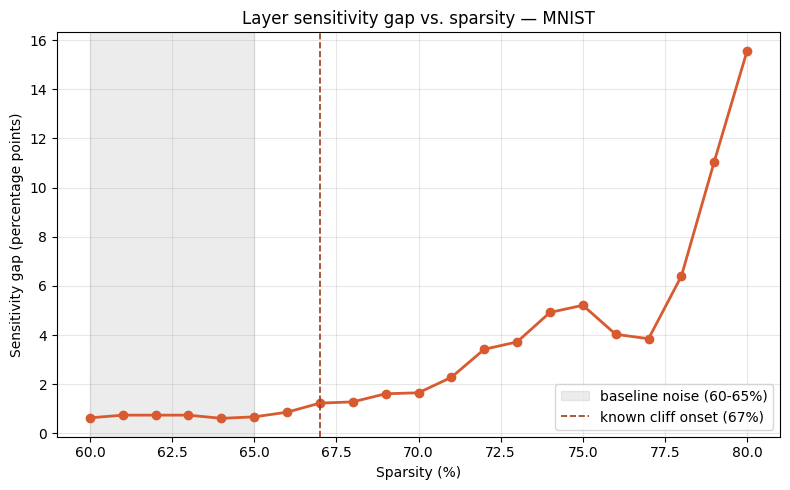

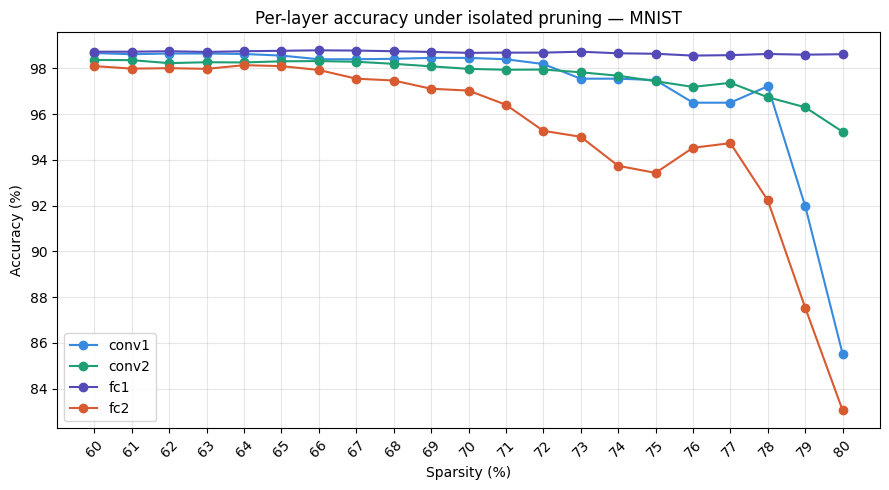

In [17]:
plt.figure(figsize=(9, 5))

colors = {'conv1': '#378ADD', 'conv2': '#1D9E75', 'fc1': '#534AB7', 'fc2': '#D85A30'}

for layer in results:
    plt.plot(sparsity_pct, results[layer], marker='o', label=layer, color=colors[layer])

plt.xticks(sparsity_pct, rotation=45)

plt.xlabel('Sparsity (%)')
plt.ylabel('Accuracy (%)')
plt.title('Per-layer accuracy under isolated pruning — MNIST')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('layer_sensitivity_raw_mnist.png', dpi=150, bbox_inches='tight')
plt.show()

In [19]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=sparsity_pct,
    y=gaps,
    mode='lines+markers',
    line=dict(color='#D85A30', width=2),
    marker=dict(size=7),
    hovertemplate='Sparsity: %{x}%<br>Gap: %{y:.2f}<extra></extra>'
))

fig.add_vrect(x0=60, x1=65, fillcolor='gray', opacity=0.15, line_width=0,
              annotation_text='baseline (60-65%)', annotation_position='top left')

fig.add_vline(x=67, line_dash='dash', line_color='#993C1D',
              annotation_text='cliff onset (67%)', annotation_position='top right')

fig.update_layout(
    xaxis_title='Sparsity (%)',
    yaxis_title='Sensitivity gap (percentage points)',
    title='Layer sensitivity gap vs. sparsity — MNIST',
    template='plotly_white'
)

fig.show()